# Comparison of WMR Fixing and TRB Prices

## 1. Data

### 1.1 Setup

In [1]:
import pandas as pd
import numpy as np
import datetime
from datetime import timedelta
import plotly.express as px
import matplotlib.pyplot as plt
import pytrendseries
import math
 
 
import warnings
warnings.filterwarnings('ignore')
 
import os
import eikon as ek
import refinitiv.data as rd
 
 
#Scroll through DF
pd.set_option("display.max_rows", None, "display.max_columns", None)
 
 
#Defining Proxy
os.environ['NO_PROXY'] = 'localhost'
os.environ['NO_PROXY'] = '127.0.0.1'
 
 
#Open Session
rd.open_session()
 
#API Key
ek.set_app_key('b7f9e07dd1664cb2b48043ec3321b0e219bc776b')
 
#Todays Datetime
dt_now = datetime.datetime.now()

0.1.11


### 1.2 Currency Universe

In [2]:
trb_pairs = [
    "EUR=TRB", 
    "EURCHF=TRB", 
    "EURJPY=TRB",
    "EURGBP=TRB", 
    "EURCZK=TRB", 
    "EURHUF=TRB" 
]

fix_pairs = [
    "EURUSDFIXMP=WM", 
    "EURCHFFIXMP=WM", 
    "EURJPYFIXMP=WM",
    "EURGBPFIXMP=WM", 
    "EURCZKFIXMP=WM", 
    "EURHUFFIXMP=WM" 
]

### 1.3 TRB Price Data

In [16]:
import pandas as pd
import time
import refinitiv.data as rd

start_date = "2026-05-13"
end_date = "2026-08-13"

dates = pd.bdate_range(
    start=start_date,
    end=end_date
)

all_data = []
failed_dates = []

for number, date in enumerate(dates, start=1):
    date_string = date.strftime("%Y-%m-%d")

    try:
        df_day = rd.get_history(
            universe=trb_pairs,
            fields=["MID_PRICE"],
            interval="60min",
            start=f"{date_string}T12:00:00",
            end=f"{date_string}T13:01:00",
            use_field_names_in_headers=True
        )

        if df_day is not None and not df_day.empty:
            df_day.index = pd.to_datetime(df_day.index)

            # Nur exakt 12:00 und 13:00 behalten
            df_day = df_day[
                (df_day.index.strftime("%H:%M") == "12:00") |
                (df_day.index.strftime("%H:%M") == "13:00")
            ]

            if not df_day.empty:
                all_data.append(df_day)

            print(
                f"[{number}/{len(dates)}] "
                f"{date_string}: {len(df_day)} Zeitpunkte"
            )
        else:
            print(
                f"[{number}/{len(dates)}] "
                f"{date_string}: keine Daten"
            )

        time.sleep(0.2)

    except Exception as error:
        failed_dates.append(date_string)

        print(
            f"[{number}/{len(dates)}] "
            f"{date_string}: Fehler: {error}"
        )

        time.sleep(1)

# Alle Tage zusammenführen
if all_data:
    df_fx = pd.concat(all_data).sort_index()

    df_fx = df_fx[
        ~df_fx.index.duplicated(keep="last")
    ]
else:
    df_fx = pd.DataFrame()

print("\nDownload abgeschlossen")
print(f"Anzahl Zeilen: {len(df_fx)}")
print(f"Fehlerhafte Tage: {failed_dates}")

display(df_fx.head())

[1/67] 2026-05-13: 2 Zeitpunkte
[2/67] 2026-05-14: 2 Zeitpunkte
[3/67] 2026-05-15: 2 Zeitpunkte
[4/67] 2026-05-18: 2 Zeitpunkte
[5/67] 2026-05-19: 2 Zeitpunkte
[6/67] 2026-05-20: 2 Zeitpunkte
[7/67] 2026-05-21: 2 Zeitpunkte
[8/67] 2026-05-22: 2 Zeitpunkte
[9/67] 2026-05-25: 2 Zeitpunkte
[10/67] 2026-05-26: 2 Zeitpunkte
[11/67] 2026-05-27: 2 Zeitpunkte
[12/67] 2026-05-28: 2 Zeitpunkte
[13/67] 2026-05-29: 2 Zeitpunkte
[14/67] 2026-06-01: 2 Zeitpunkte
[15/67] 2026-06-02: 2 Zeitpunkte
[16/67] 2026-06-03: 2 Zeitpunkte
[17/67] 2026-06-04: 2 Zeitpunkte
[18/67] 2026-06-05: 2 Zeitpunkte
[19/67] 2026-06-08: 2 Zeitpunkte
[20/67] 2026-06-09: 2 Zeitpunkte
[21/67] 2026-06-10: 2 Zeitpunkte
[22/67] 2026-06-11: 2 Zeitpunkte
[23/67] 2026-06-12: 2 Zeitpunkte
[24/67] 2026-06-15: 2 Zeitpunkte
[25/67] 2026-06-16: 2 Zeitpunkte
[26/67] 2026-06-17: 2 Zeitpunkte
[27/67] 2026-06-18: 2 Zeitpunkte
[28/67] 2026-06-19: 2 Zeitpunkte
[29/67] 2026-06-22: 2 Zeitpunkte
[30/67] 2026-06-23: 2 Zeitpunkte
[31/67] 2026-06-24:

MID_PRICE,EUR=TRB,EURCHF=TRB,EURJPY=TRB,EURGBP=TRB,EURCZK=TRB,EURHUF=TRB
Timestamp,,,,,,
2026-05-13 12:00:00,1.17020,0.91600,184.71000,0.86740,24.34900,358.48500
2026-05-13 13:00:00,1.17100,0.91585,184.75500,0.86650,24.34500,357.97500
2026-05-14 12:00:00,1.16975,0.91480,184.78500,0.86595,24.30600,357.34500
2026-05-14 13:00:00,1.16895,0.91450,184.59000,0.86590,24.30700,357.29500
2026-05-15 12:00:00,1.16265,0.91465,184.37000,0.87065,24.34300,360.33500


In [ ]:
df_fx.to_csv(
    "fx_mid_prices_12_13.csv",
    index=True,
    index_label="Timestamp",
    sep=";",
    decimal=",",
    encoding="utf-8-sig"
)

print("CSV erfolgreich gespeichert.")

### 1.4 WMR Fixing Data

In [15]:
import pandas as pd
import refinitiv.data as rd


# ---------------------------------------------------------
# Einstellungen
# ---------------------------------------------------------

fix_pairs = [
    "EURUSDFIXMP=WM",
    "EURCHFFIXMP=WM",
    "EURJPYFIXMP=WM",
    "EURGBPFIXMP=WM",
    "EURCZKFIXMP=WM",
    "EURHUFFIXMP=WM"
]

start_date = "2026-05-13"
end_date = "2026-08-13"


# ---------------------------------------------------------
# WMR-Fixings herunterladen
# ---------------------------------------------------------

df_fix = rd.get_history(
    universe=fix_pairs,
    fields=["QUOTE_VAL"],
    interval="60min",
    start=f"{start_date}T00:00:00",
    end=f"{end_date}T23:59:59",
    use_field_names_in_headers=True
)


# ---------------------------------------------------------
# Daten aufbereiten
# ---------------------------------------------------------

if df_fix is not None and not df_fix.empty:

    df_fix = df_fix.copy()

    # Zeitindex sicher in Datetime umwandeln
    df_fix.index = pd.to_datetime(df_fix.index)

    # Nur 12:00- und 13:00-Fixings behalten
    df_fix = df_fix[
        df_fix.index.hour.isin([12, 13])
    ]

    # Wochenenden entfernen
    df_fix = df_fix[
        df_fix.index.dayofweek < 5
    ]

    # Doppelte Zeitstempel vorsichtshalber entfernen
    df_fix = df_fix[
        ~df_fix.index.duplicated(keep="last")
    ]

    # Chronologisch sortieren
    df_fix = df_fix.sort_index()

else:
    df_fix = pd.DataFrame()


# ---------------------------------------------------------
# Ergebnis prüfen
# ---------------------------------------------------------

print("Download abgeschlossen")
print(f"Zeitraum: {start_date} bis {end_date}")
print(f"Anzahl Zeitpunkte: {len(df_fix)}")

if not df_fix.empty:
    print(f"Erster Zeitstempel: {df_fix.index.min()}")
    print(f"Letzter Zeitstempel: {df_fix.index.max()}")
    print(f"Anzahl vorhandener Einzelwerte: {df_fix.notna().sum().sum()}")
    print(f"Anzahl fehlender Einzelwerte: {df_fix.isna().sum().sum()}")

display(df_fix.head(10))


Download abgeschlossen
Zeitraum: 2026-05-13 bis 2026-08-13
Anzahl Zeitpunkte: 134
Erster Zeitstempel: 2026-05-13 12:00:00
Letzter Zeitstempel: 2026-08-13 13:00:00
Anzahl vorhandener Einzelwerte: 804
Anzahl fehlender Einzelwerte: 0


QUOTE_VAL,EURUSDFIXMP=WM,EURCHFFIXMP=WM,EURJPYFIXMP=WM,EURGBPFIXMP=WM,EURCZKFIXMP=WM,EURHUFFIXMP=WM
Timestamp,,,,,,
2026-05-13 12:00:00,1.17125,0.91530,184.78810,0.86735,24.34750,358.70000
2026-05-13 13:00:00,1.17040,0.91615,184.75345,0.86745,24.34850,358.55000
2026-05-14 12:00:00,1.17020,0.91505,184.85065,0.86675,24.29900,357.52500
2026-05-14 13:00:00,1.16965,0.91465,184.78715,0.86585,24.30700,357.32500
2026-05-15 12:00:00,1.16310,0.91430,184.43860,0.87065,24.32900,359.47500
2026-05-15 13:00:00,1.16275,0.91475,184.38310,0.87060,24.34250,360.37500
2026-05-18 12:00:00,1.16415,0.91440,184.90780,0.87035,24.32150,361.10000
2026-05-18 13:00:00,1.16515,0.91465,184.92100,0.86975,24.31150,360.15000
2026-05-19 12:00:00,1.16175,0.91505,184.85770,0.86670,24.29700,360.80000


In [17]:
df_fix.to_csv(
    "wmr_fixings_12_13.csv",
    index=True,
    index_label="Timestamp",
    sep=";",
    decimal=",",
    encoding="utf-8-sig"
)

print("CSV erfolgreich gespeichert.")

CSV erfolgreich gespeichert.


## 2. Analysis

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

trb_file = "fx_mid_prices_12_13.csv"
wmr_file = "wmr_fixings_12_13.csv"

df_trb = pd.read_csv(
    trb_file,
    sep=";",
    decimal=",",
    parse_dates=["Timestamp"]
)

df_wmr = pd.read_csv(
    wmr_file,
    sep=";",
    decimal=",",
    parse_dates=["Timestamp"]
)

print("TRB:", df_trb.shape)
print("WMR:", df_wmr.shape)

display(df_trb.head())
display(df_wmr.head())

TRB: (134, 7)
WMR: (134, 7)


,Timestamp,EUR=TRB,EURCHF=TRB,EURJPY=TRB,EURGBP=TRB,EURCZK=TRB,EURHUF=TRB
0,2026-05-13 12:00:00,1.17020,0.91600,184.71000,0.86740,24.34900,358.48500
1,2026-05-13 13:00:00,1.17100,0.91585,184.75500,0.86650,24.34500,357.97500
2,2026-05-14 12:00:00,1.16975,0.91480,184.78500,0.86595,24.30600,357.34500
3,2026-05-14 13:00:00,1.16895,0.91450,184.59000,0.86590,24.30700,357.29500
4,2026-05-15 12:00:00,1.16265,0.91465,184.37000,0.87065,24.34300,360.33500


,Timestamp,EURUSDFIXMP=WM,EURCHFFIXMP=WM,EURJPYFIXMP=WM,EURGBPFIXMP=WM,EURCZKFIXMP=WM,EURHUFFIXMP=WM
0,2026-05-13 12:00:00,1.17125,0.91530,184.78810,0.86735,24.34750,358.70000
1,2026-05-13 13:00:00,1.17040,0.91615,184.75345,0.86745,24.34850,358.55000
2,2026-05-14 12:00:00,1.17020,0.91505,184.85065,0.86675,24.29900,357.52500
3,2026-05-14 13:00:00,1.16965,0.91465,184.78715,0.86585,24.30700,357.32500
4,2026-05-15 12:00:00,1.16310,0.91430,184.43860,0.87065,24.32900,359.47500


In [20]:
trb_rename = {
    "EUR=TRB": "EURUSD",
    "EURCHF=TRB": "EURCHF",
    "EURJPY=TRB": "EURJPY",
    "EURGBP=TRB": "EURGBP",
    "EURCZK=TRB": "EURCZK",
    "EURHUF=TRB": "EURHUF"
}

wmr_rename = {
    "EURUSDFIXMP=WM": "EURUSD",
    "EURCHFFIXMP=WM": "EURCHF",
    "EURJPYFIXMP=WM": "EURJPY",
    "EURGBPFIXMP=WM": "EURGBP",
    "EURCZKFIXMP=WM": "EURCZK",
    "EURHUFFIXMP=WM": "EURHUF"
}

df_trb = df_trb.rename(columns=trb_rename)
df_wmr = df_wmr.rename(columns=wmr_rename)

pairs = [
    "EURUSD",
    "EURCHF",
    "EURJPY",
    "EURGBP",
    "EURCZK",
    "EURHUF"
]

In [22]:
print("TRB-Zeitraum:")
print(df_trb["Timestamp"].min(), "bis", df_trb["Timestamp"].max())

print("\nWMR-Zeitraum:")
print(df_wmr["Timestamp"].min(), "bis", df_wmr["Timestamp"].max())

print("\nFehlende Werte TRB:")
display(df_trb.isna().sum().to_frame("Missing_TRB"))

print("\nFehlende Werte WMR:")
display(df_wmr.isna().sum().to_frame("Missing_WMR"))

print("\nDoppelte TRB-Zeitstempel:", df_trb["Timestamp"].duplicated().sum())
print("Doppelte WMR-Zeitstempel:", df_wmr["Timestamp"].duplicated().sum())


TRB-Zeitraum:
2026-05-13 12:00:00 bis 2026-08-13 13:00:00

WMR-Zeitraum:
2026-05-13 12:00:00 bis 2026-08-13 13:00:00

Fehlende Werte TRB:


,Missing_TRB
Timestamp,0
EURUSD,0
EURCHF,0
EURJPY,0
EURGBP,0
EURCZK,0
EURHUF,0



Fehlende Werte WMR:


,Missing_WMR
Timestamp,0
EURUSD,0
EURCHF,0
EURJPY,0
EURGBP,0
EURCZK,0
EURHUF,0



Doppelte TRB-Zeitstempel: 0
Doppelte WMR-Zeitstempel: 0


In [23]:
timestamp_check = df_trb[["Timestamp"]].merge(
    df_wmr[["Timestamp"]],
    on="Timestamp",
    how="outer",
    indicator=True
)

display(timestamp_check["_merge"].value_counts())

_merge
both          134
left_only       0
right_only      0
Name: count, dtype: int64

In [24]:
trb_long = df_trb.melt(
    id_vars="Timestamp",
    value_vars=pairs,
    var_name="Pair",
    value_name="TRB"
)

wmr_long = df_wmr.melt(
    id_vars="Timestamp",
    value_vars=pairs,
    var_name="Pair",
    value_name="WMR"
)

comparison = trb_long.merge(
    wmr_long,
    on=["Timestamp", "Pair"],
    how="inner",
    validate="one_to_one"
)

comparison["Date"] = comparison["Timestamp"].dt.normalize()
comparison["Hour"] = comparison["Timestamp"].dt.hour

display(comparison.head(12))

,Timestamp,Pair,TRB,WMR,Date,Hour
0,2026-05-13 12:00:00,EURUSD,1.17020,1.17125,2026-05-13,12
1,2026-05-13 13:00:00,EURUSD,1.17100,1.17040,2026-05-13,13
2,2026-05-14 12:00:00,EURUSD,1.16975,1.17020,2026-05-14,12
3,2026-05-14 13:00:00,EURUSD,1.16895,1.16965,2026-05-14,13
4,2026-05-15 12:00:00,EURUSD,1.16265,1.16310,2026-05-15,12
5,2026-05-15 13:00:00,EURUSD,1.16235,1.16275,2026-05-15,13
6,2026-05-18 12:00:00,EURUSD,1.16515,1.16415,2026-05-18,12
7,2026-05-18 13:00:00,EURUSD,1.16510,1.16515,2026-05-18,13
8,2026-05-19 12:00:00,EURUSD,1.16170,1.16175,2026-05-19,12
9,2026-05-19 13:00:00,EURUSD,1.16135,1.16175,2026-05-19,13


In [26]:
comparison["Difference"] = (
    comparison["TRB"] - comparison["WMR"]
)

comparison["Absolute_Difference"] = (
    comparison["Difference"].abs()
)

comparison["Difference_bps"] = (
    comparison["Difference"] / comparison["WMR"] * 10_000
)

comparison["Absolute_Difference_bps"] = (
    comparison["Difference_bps"].abs()
)

comparison["Difference_pct"] = (
    comparison["Difference"] / comparison["WMR"] * 100
)

comparison["Squared_Error_bps"] = (
    comparison["Difference_bps"] ** 2
)

display(comparison.head())


,Timestamp,Pair,TRB,WMR,Date,Hour,Difference,Absolute_Difference,Difference_bps,Absolute_Difference_bps,Difference_pct,Squared_Error_bps
0,2026-05-13 12:00:00,EURUSD,1.17020,1.17125,2026-05-13,12,-0.00105,0.00105,-8.96478,8.96478,-0.08965,80.36730
1,2026-05-13 13:00:00,EURUSD,1.17100,1.17040,2026-05-13,13,0.00060,0.00060,5.12645,5.12645,0.05126,26.28052
2,2026-05-14 12:00:00,EURUSD,1.16975,1.17020,2026-05-14,12,-0.00045,0.00045,-3.84550,3.84550,-0.03845,14.78784
3,2026-05-14 13:00:00,EURUSD,1.16895,1.16965,2026-05-14,13,-0.00070,0.00070,-5.98470,5.98470,-0.05985,35.81659
4,2026-05-15 12:00:00,EURUSD,1.16265,1.16310,2026-05-15,12,-0.00045,0.00045,-3.86897,3.86897,-0.03869,14.96894


In [27]:
summary_by_pair = (
    comparison
    .groupby("Pair")
    .agg(
        Observations=("Difference_bps", "count"),
        Mean_Bias_bps=("Difference_bps", "mean"),
        Median_Bias_bps=("Difference_bps", "median"),
        MAE_bps=("Absolute_Difference_bps", "mean"),
        Median_AE_bps=("Absolute_Difference_bps", "median"),
        RMSE_bps=(
            "Squared_Error_bps",
            lambda x: np.sqrt(x.mean())
        ),
        Std_bps=("Difference_bps", "std"),
        P95_Absolute_bps=(
            "Absolute_Difference_bps",
            lambda x: x.quantile(0.95)
        ),
        Max_Absolute_bps=("Absolute_Difference_bps", "max"),
        Correlation=(
            "TRB",
            lambda x: x.corr(
                comparison.loc[x.index, "WMR"]
            )
        )
    )
    .sort_values("MAE_bps")
)

display(
    summary_by_pair.style.format({
        "Mean_Bias_bps": "{:.3f}",
        "Median_Bias_bps": "{:.3f}",
        "MAE_bps": "{:.3f}",
        "Median_AE_bps": "{:.3f}",
        "RMSE_bps": "{:.3f}",
        "Std_bps": "{:.3f}",
        "P95_Absolute_bps": "{:.3f}",
        "Max_Absolute_bps": "{:.3f}",
        "Correlation": "{:.6f}"
    })
)

,Observations,Mean_Bias_bps,Median_Bias_bps,MAE_bps,Median_AE_bps,RMSE_bps,Std_bps,P95_Absolute_bps,Max_Absolute_bps,Correlation
Pair,,,,,,,,,,
EURCZK,134,-0.200,-0.412,2.607,2.065,3.350,3.356,6.189,13.227,0.987114
EURGBP,134,-0.234,0.000,4.290,2.937,6.002,6.020,11.590,30.148,0.995814
EURCHF,134,-0.061,0.000,4.667,3.265,6.425,6.449,12.942,33.782,0.996286
EURJPY,134,-1.772,0.705,6.733,3.654,16.370,16.335,17.819,153.672,0.967994
EURUSD,134,0.212,-0.863,7.250,4.969,11.099,11.139,22.624,46.815,0.992087
EURHUF,134,-1.573,-0.212,10.561,8.055,14.193,14.159,28.387,40.877,0.992487


In [28]:
summary_by_pair_hour = (
    comparison
    .groupby(["Pair", "Hour"])
    .agg(
        Observations=("Difference_bps", "count"),
        Mean_Bias_bps=("Difference_bps", "mean"),
        MAE_bps=("Absolute_Difference_bps", "mean"),
        RMSE_bps=(
            "Squared_Error_bps",
            lambda x: np.sqrt(x.mean())
        ),
        P95_Absolute_bps=(
            "Absolute_Difference_bps",
            lambda x: x.quantile(0.95)
        ),
        Max_Absolute_bps=("Absolute_Difference_bps", "max")
    )
    .reset_index()
)

display(
    summary_by_pair_hour.style.format({
        "Mean_Bias_bps": "{:.3f}",
        "MAE_bps": "{:.3f}",
        "RMSE_bps": "{:.3f}",
        "P95_Absolute_bps": "{:.3f}",
        "Max_Absolute_bps": "{:.3f}"
    })
)

,Pair,Hour,Observations,Mean_Bias_bps,MAE_bps,RMSE_bps,P95_Absolute_bps,Max_Absolute_bps
0,EURCHF,12,67,0.659,4.474,5.655,11.949,14.785
1,EURCHF,13,67,-0.781,4.860,7.113,12.338,33.782
2,EURCZK,12,67,-0.178,2.341,3.121,5.776,13.227
3,EURCZK,13,67,-0.222,2.872,3.563,6.212,9.293
4,EURGBP,12,67,0.812,4.420,6.640,12.790,30.148
5,EURGBP,13,67,-1.281,4.161,5.287,10.651,14.055
6,EURHUF,12,67,-2.358,10.190,14.147,30.457,40.877
7,EURHUF,13,67,-0.788,10.933,14.239,27.595,37.566
8,EURJPY,12,67,0.267,4.911,7.445,15.986,26.641
9,EURJPY,13,67,-3.811,8.556,21.921,18.381,153.672


In [29]:
hour_comparison = summary_by_pair_hour.pivot(
    index="Pair",
    columns="Hour",
    values=[
        "Mean_Bias_bps",
        "MAE_bps",
        "RMSE_bps",
        "P95_Absolute_bps"
    ]
)

display(hour_comparison.round(3))

Mean_Bias_bps           MAE_bps          RMSE_bps          P95_Absolute_bps         
Hour              12       13       12       13       12       13               12       13
Pair                                                                                       
EURCHF       0.65900 -0.78100  4.47400  4.86000  5.65500  7.11300         11.94900 12.33800
EURCZK      -0.17800 -0.22200  2.34100  2.87200  3.12100  3.56300          5.77600  6.21200
EURGBP       0.81200 -1.28100  4.42000  4.16100  6.64000  5.28700         12.79000 10.65100
EURHUF      -2.35800 -0.78800 10.19000 10.93300 14.14700 14.23900         30.45700 27.59500
EURJPY       0.26700 -3.81100  4.91100  8.55600  7.44500 21.92100         15.98600 18.38100
EURUSD       1.33500 -0.91100  7.58600  6.91300 12.09600 10.00400         30.69400 18.80100

In [30]:
threshold_summary = (
    comparison
    .groupby("Pair")
    .agg(
        Within_1bp=(
            "Absolute_Difference_bps",
            lambda x: (x <= 1).mean() * 100
        ),
        Within_2bp=(
            "Absolute_Difference_bps",
            lambda x: (x <= 2).mean() * 100
        ),
        Within_5bp=(
            "Absolute_Difference_bps",
            lambda x: (x <= 5).mean() * 100
        ),
        Above_10bp=(
            "Absolute_Difference_bps",
            lambda x: (x > 10).mean() * 100
        )
    )
)

display(
    threshold_summary.style.format("{:.1f}%")
)

,Within_1bp,Within_2bp,Within_5bp,Above_10bp
Pair,,,,
EURCHF,9.0%,26.1%,68.7%,7.5%
EURCZK,21.6%,47.8%,87.3%,0.7%
EURGBP,16.4%,33.6%,68.7%,9.0%
EURHUF,11.2%,19.4%,35.1%,39.6%
EURJPY,11.9%,27.6%,63.4%,14.2%
EURUSD,14.9%,21.6%,50.0%,20.9%


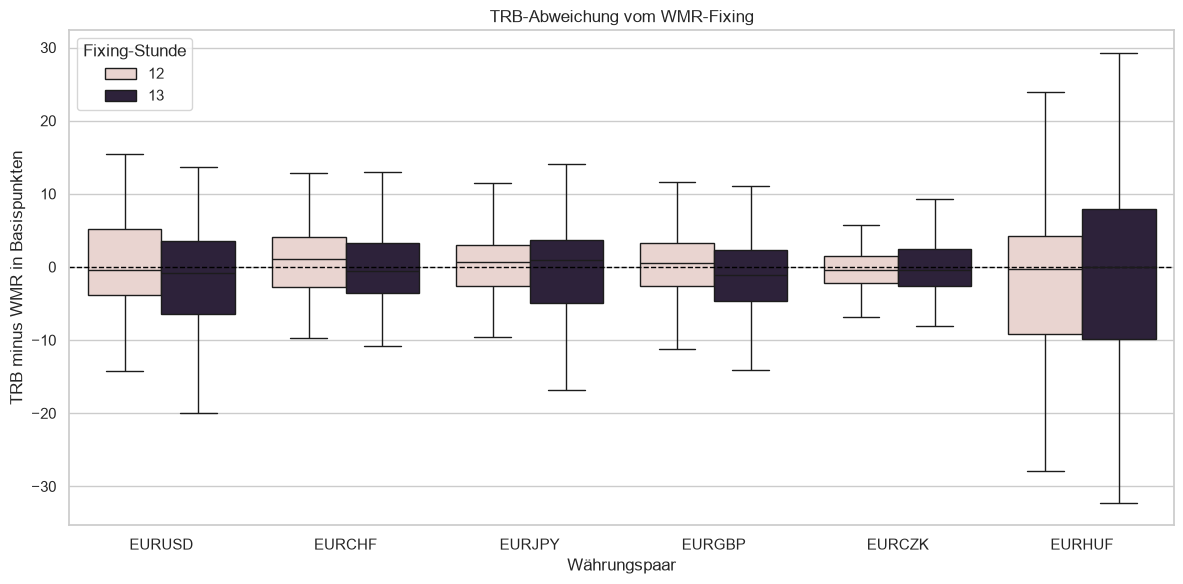

In [31]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=comparison,
    x="Pair",
    y="Difference_bps",
    hue="Hour",
    showfliers=False
)

plt.axhline(
    0,
    color="black",
    linewidth=1,
    linestyle="--"
)

plt.title("TRB-Abweichung vom WMR-Fixing")
plt.xlabel("Währungspaar")
plt.ylabel("TRB minus WMR in Basispunkten")
plt.legend(title="Fixing-Stunde")

plt.tight_layout()
plt.show()

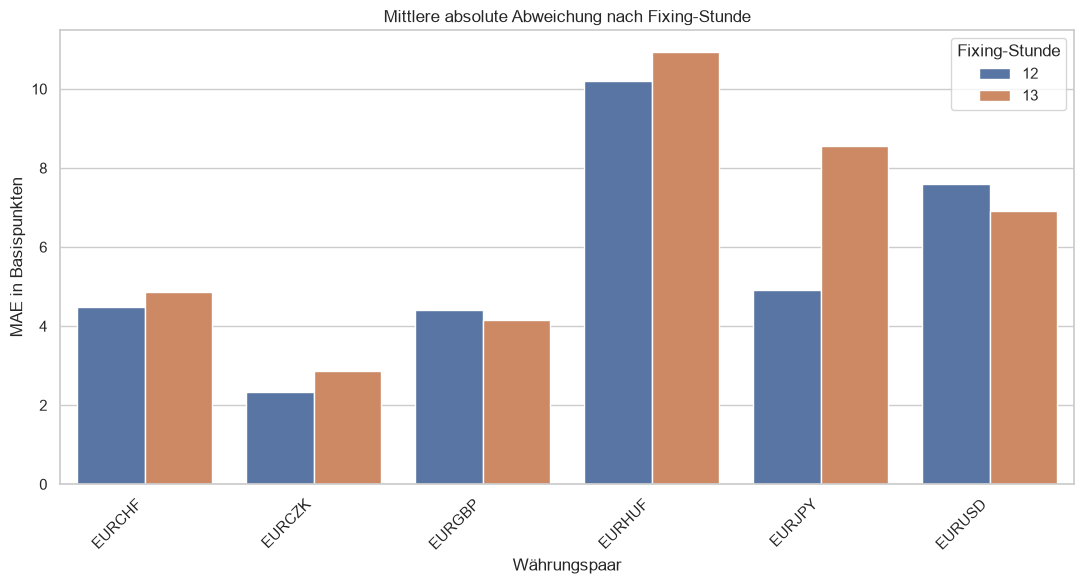

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# MAE je Währungspaar und Fixing-Stunde berechnen
mae_chart = (
    comparison
    .groupby(["Pair", "Hour"], as_index=False)
    .agg(
        MAE_bps=(
            "Absolute_Difference_bps",
            "mean"
        )
    )
)

mae_chart["Hour"] = mae_chart["Hour"].astype(str)

# Chart 10
plt.figure(figsize=(11, 6))

sns.barplot(
    data=mae_chart,
    x="Pair",
    y="MAE_bps",
    hue="Hour"
)

plt.title("Mittlere absolute Abweichung nach Fixing-Stunde")
plt.xlabel("Währungspaar")
plt.ylabel("MAE in Basispunkten")
plt.legend(title="Fixing-Stunde")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

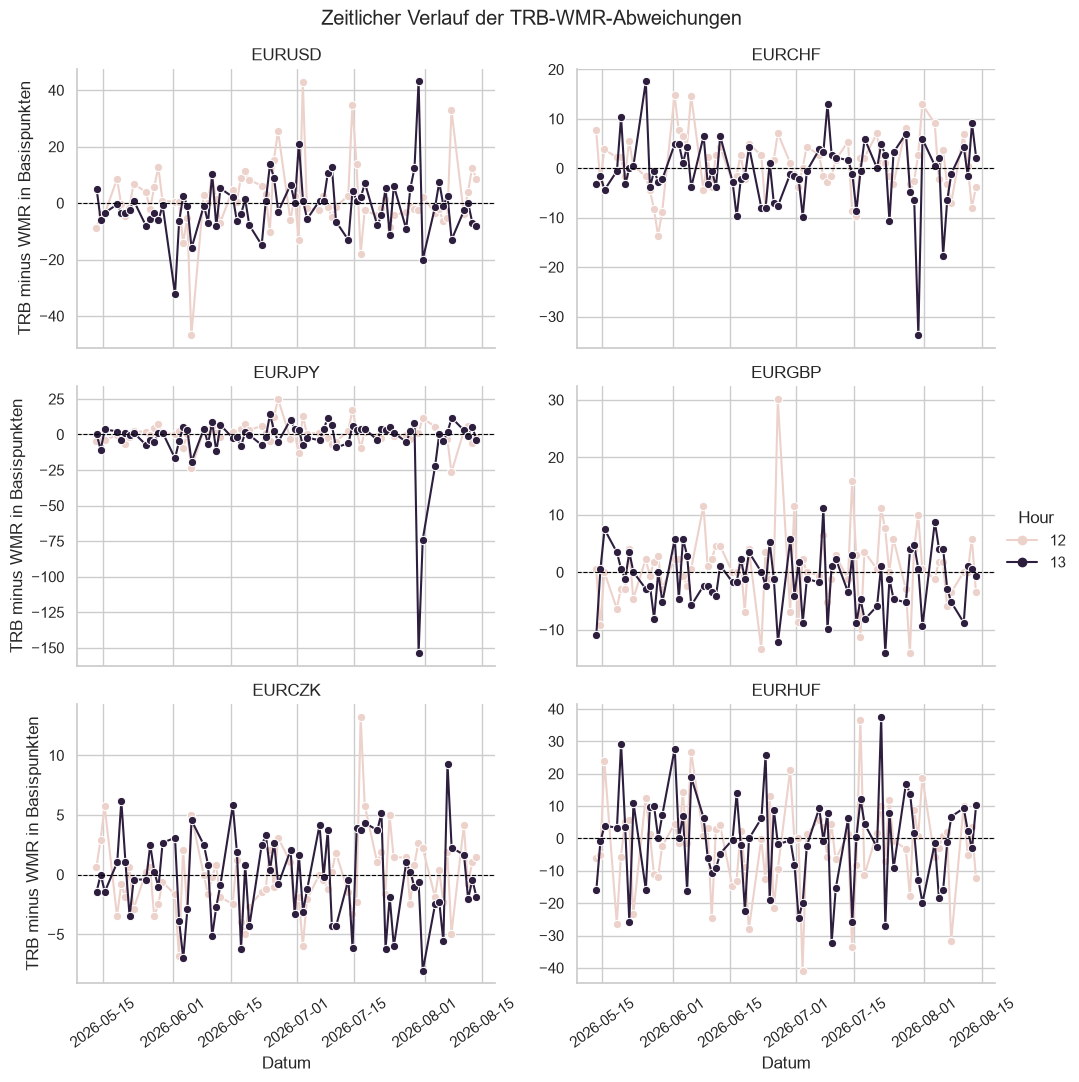

In [32]:
g = sns.relplot(
    data=comparison,
    x="Timestamp",
    y="Difference_bps",
    col="Pair",
    hue="Hour",
    kind="line",
    marker="o",
    col_wrap=2,
    height=3.4,
    aspect=1.5,
    facet_kws={"sharey": False}
)

g.set_axis_labels(
    "Datum",
    "TRB minus WMR in Basispunkten"
)

g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.axhline(
        0,
        color="black",
        linewidth=0.8,
        linestyle="--"
    )
    ax.tick_params(axis="x", rotation=35)

g.figure.suptitle(
    "Zeitlicher Verlauf der TRB-WMR-Abweichungen",
    y=1.02
)

plt.show()

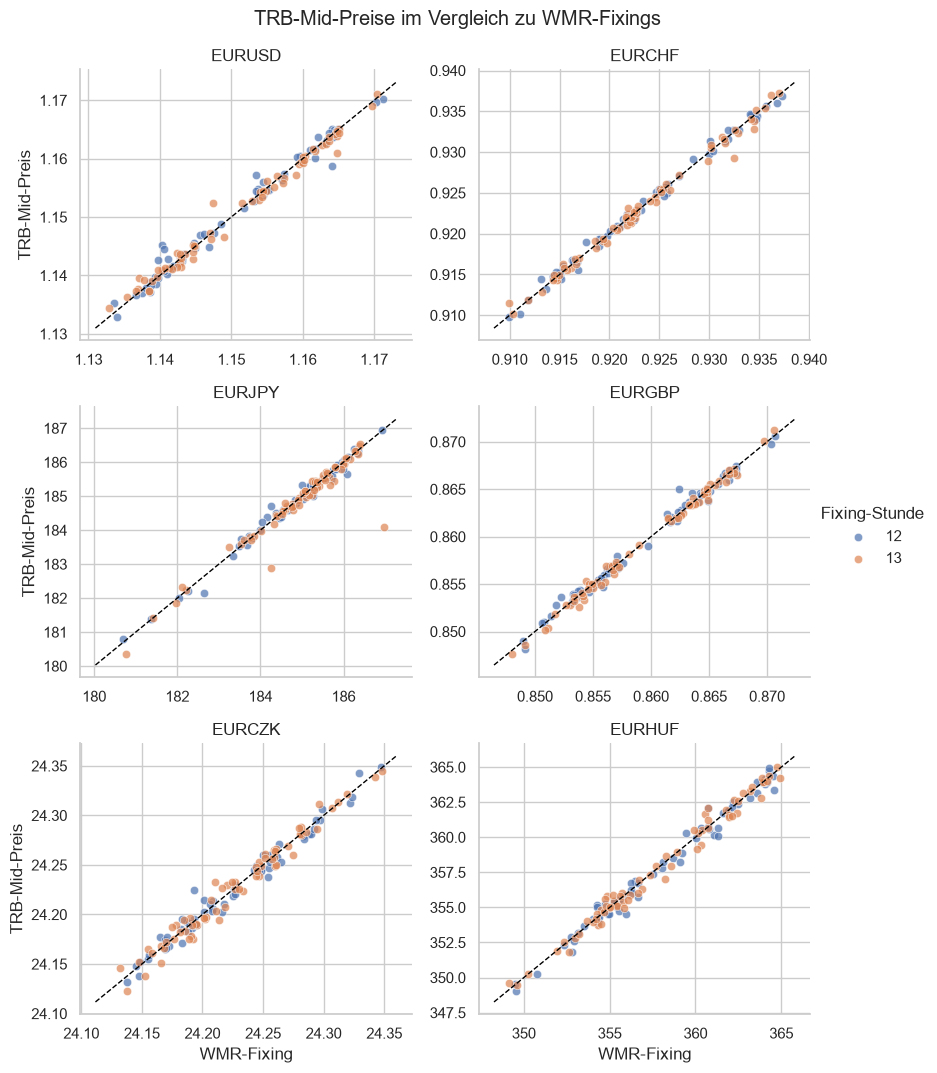

In [33]:
g = sns.FacetGrid(
    comparison,
    col="Pair",
    hue="Hour",
    col_wrap=2,
    height=3.5,
    aspect=1.2,
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="WMR",
    y="TRB",
    alpha=0.7
)

# 45-Grad-Linie je Teilchart
for ax in g.axes.flat:
    low = min(
        ax.get_xlim()[0],
        ax.get_ylim()[0]
    )
    high = max(
        ax.get_xlim()[1],
        ax.get_ylim()[1]
    )

    ax.plot(
        [low, high],
        [low, high],
        color="black",
        linestyle="--",
        linewidth=1
    )

g.add_legend(title="Fixing-Stunde")
g.set_axis_labels("WMR-Fixing", "TRB-Mid-Preis")
g.set_titles("{col_name}")

g.figure.suptitle(
    "TRB-Mid-Preise im Vergleich zu WMR-Fixings",
    y=1.02
)

plt.show()

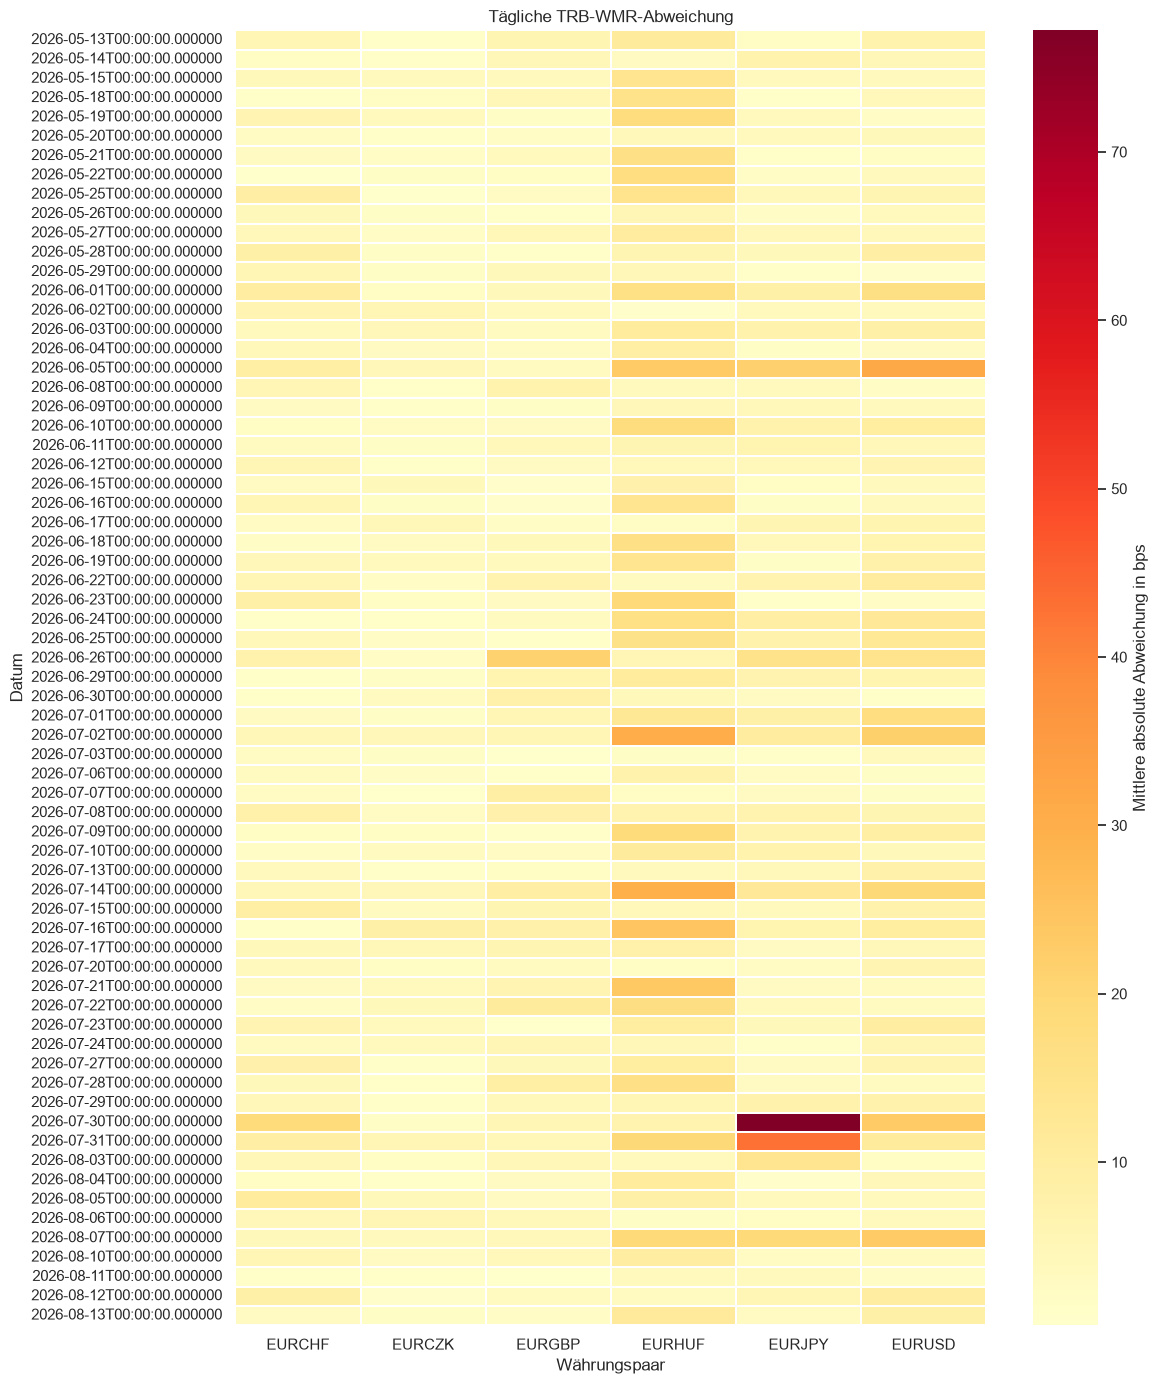

In [34]:
daily_mae = (
    comparison
    .groupby(["Date", "Pair"])
    ["Absolute_Difference_bps"]
    .mean()
    .unstack("Pair")
)

plt.figure(figsize=(12, 14))

sns.heatmap(
    daily_mae,
    cmap="YlOrRd",
    linewidths=0.2,
    cbar_kws={
        "label": "Mittlere absolute Abweichung in bps"
    }
)

plt.title("Tägliche TRB-WMR-Abweichung")
plt.xlabel("Währungspaar")
plt.ylabel("Datum")

plt.tight_layout()
plt.show()

In [35]:
largest_outliers = (
    comparison
    .sort_values(
        "Absolute_Difference_bps",
        ascending=False
    )
    [[
        "Timestamp",
        "Hour",
        "Pair",
        "TRB",
        "WMR",
        "Difference",
        "Difference_bps",
        "Absolute_Difference_bps"
    ]]
    .head(20)
)

display(
    largest_outliers.style.format({
        "TRB": "{:.6f}",
        "WMR": "{:.6f}",
        "Difference": "{:.6f}",
        "Difference_bps": "{:.3f}",
        "Absolute_Difference_bps": "{:.3f}"
    })
)


,Timestamp,Hour,Pair,TRB,WMR,Difference,Difference_bps,Absolute_Difference_bps
381,2026-07-30 13:00:00,13,EURJPY,184.090000,186.963100,-2.873100,-153.672,153.672
383,2026-07-31 13:00:00,13,EURJPY,182.890000,184.251350,-1.361350,-73.885,73.885
34,2026-06-05 12:00:00,12,EURUSD,1.158700,1.164150,-0.005450,-46.815,46.815
113,2026-07-30 13:00:00,13,EURUSD,1.152350,1.147400,0.004950,43.141,43.141
72,2026-07-02 12:00:00,12,EURUSD,1.145150,1.140250,0.004900,42.973,42.973
742,2026-07-02 12:00:00,12,EURHUF,354.495000,355.950000,-1.455000,-40.877,40.877
769,2026-07-21 13:00:00,13,EURHUF,362.055000,360.700000,1.355000,37.566,37.566
762,2026-07-16 12:00:00,12,EURHUF,362.070000,360.750000,1.320000,36.590,36.590
88,2026-07-14 12:00:00,12,EURUSD,1.144600,1.140650,0.003950,34.629,34.629
247,2026-07-30 13:00:00,13,EURCHF,0.929300,0.932450,-0.003150,-33.782,33.782


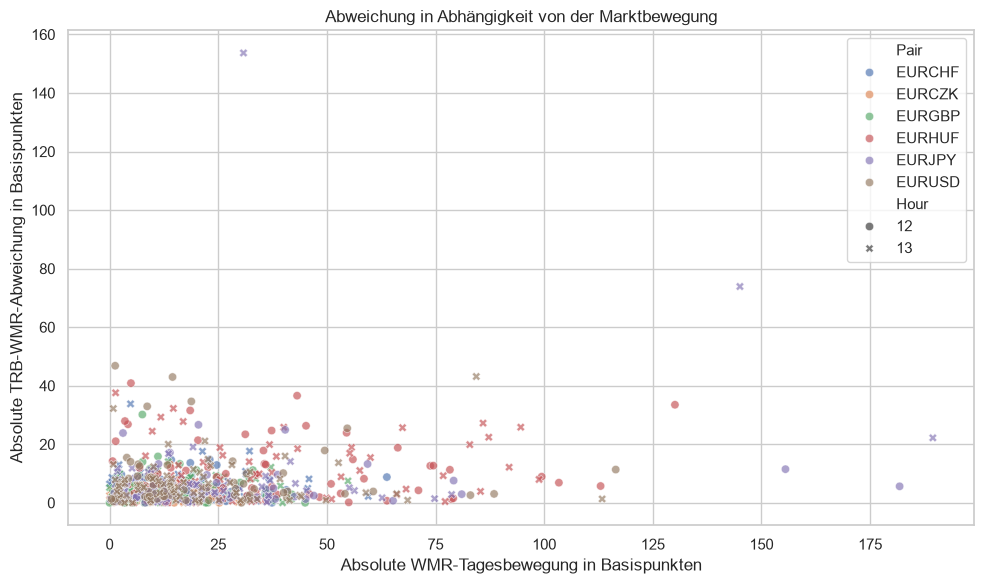

In [36]:
comparison = comparison.sort_values(
    ["Pair", "Hour", "Timestamp"]
)

comparison["WMR_Return_bps"] = (
    comparison
    .groupby(["Pair", "Hour"])["WMR"]
    .pct_change()
    .mul(10_000)
)

comparison["Absolute_WMR_Return_bps"] = (
    comparison["WMR_Return_bps"].abs()
)

volatility_relation = (
    comparison
    .dropna(
        subset=[
            "Absolute_WMR_Return_bps",
            "Absolute_Difference_bps"
        ]
    )
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=volatility_relation,
    x="Absolute_WMR_Return_bps",
    y="Absolute_Difference_bps",
    hue="Pair",
    style="Hour",
    alpha=0.65
)

plt.title("Abweichung in Abhängigkeit von der Marktbewegung")
plt.xlabel("Absolute WMR-Tagesbewegung in Basispunkten")
plt.ylabel("Absolute TRB-WMR-Abweichung in Basispunkten")

plt.tight_layout()
plt.show()

In [37]:
volatility_summary = (
    volatility_relation
    .groupby("Pair")
    .apply(
        lambda group: pd.Series({
            "Correlation_Movement_Error": (
                group["Absolute_WMR_Return_bps"]
                .corr(group["Absolute_Difference_bps"])
            )
        }),
        include_groups=False
    )
)

display(volatility_summary.round(3))

,Correlation_Movement_Error
Pair,
EURCHF,0.05700
EURCZK,0.09100
EURGBP,0.04800
EURHUF,0.09500
EURJPY,0.21000
EURUSD,0.02300


In [38]:
overall_summary = pd.Series({
    "Observations": len(comparison),
    "Mean_Bias_bps": comparison["Difference_bps"].mean(),
    "MAE_bps": comparison["Absolute_Difference_bps"].mean(),
    "RMSE_bps": np.sqrt(
        comparison["Squared_Error_bps"].mean()
    ),
    "Median_Absolute_bps": (
        comparison["Absolute_Difference_bps"].median()
    ),
    "P95_Absolute_bps": (
        comparison["Absolute_Difference_bps"].quantile(0.95)
    ),
    "Maximum_Absolute_bps": (
        comparison["Absolute_Difference_bps"].max()
    ),
    "Share_Within_2bps_pct": (
        comparison["Absolute_Difference_bps"]
        .le(2)
        .mean()
        * 100
    )
})

display(
    overall_summary.to_frame("Value").style.format("{:.3f}")
)

,Value
Observations,804.000
Mean_Bias_bps,-0.605
MAE_bps,6.018
RMSE_bps,10.655
Median_Absolute_bps,3.561
P95_Absolute_bps,19.747
Maximum_Absolute_bps,153.672
Share_Within_2bps_pct,29.353
